In [3]:
import os
import cv2
import numpy as np
import pandas as pd

def calculate_density(folder_path):
    results_list = []
    
    folders = os.listdir(folder_path)
    
    for folder in folders:
        if folder == ".DS_Store": # Ignore mac hidden files
            continue
            
        full_path = folder_path + "/" + folder
        
        if os.path.isdir(full_path):
            print(folder)
            
            all_files = os.listdir(full_path)
            all_files.sort()
            
            for file_name in all_files:
                if file_name.endswith(".jpg") or file_name.endswith(".png"):
                    
                    # get the number from the filename (e.g. frame_120.jpg)
                    parts = file_name.split("_")
                    last_part = parts[-1]
                    frame_num = int(last_part.split(".")[0])
                    
                    img = cv2.imread(full_path + "/" + file_name)
                    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                    
                    # resize so its faster
                    resized = cv2.resize(gray, (640, 360))
                    
                    # blur then sobel for edges
                    blur = cv2.GaussianBlur(resized, (5, 5), 0)
                    x_edges = cv2.Sobel(blur, cv2.CV_64F, 1, 0, ksize=3)
                    y_edges = cv2.Sobel(blur, cv2.CV_64F, 0, 1, ksize=3)
                    
                    abs_x = np.absolute(x_edges)
                    abs_y = np.absolute(y_edges)
                    combined_edges = abs_x + abs_y
                    
                    # average edge brightness = how much crowd/detail there is
                    sum_pixels = np.sum(combined_edges)
                    total_area = combined_edges.shape[0] * combined_edges.shape[1]
                    density = sum_pixels / total_area
                    
                    data_row = {
                        "dj": folder,
                        "time": frame_num,
                        "score": density
                    }
                    results_list.append(data_row)

    final_df = pd.DataFrame(results_list)
    return final_df


df = calculate_density("filtered_frames")
print(df.head())


Yaeji  Boiler Room New York - Boiler Room (720p, h264)
Funky Disco & House Mix Inside a Circus  Felix da Housecat - Book Club Radio (720p, h264, youtube)
Yung Singh  Boiler Room Melbourne - Boiler Room (720p, h264, youtube)
ALISHA Groovy Tech-House DJ Set Live From DJ Mag HQ - DJ Mag (720p, h264, youtube)
Fred again.. ｜ Boiler Room： London
KETTAMA  Boiler Room London - Boiler Room (720p, h264)
Marlon Hoffstadt  Boiler Room Melbourne - Boiler Room (720p, h264)
AZYR  Boiler Room x Teletech Festival 2023 - Boiler Room (720p, h264)
¥ØUUK€ ¥UK1MATU  Boiler Room Tokyo - Boiler Room (720p, h264)
Chase & Status  Boiler Room London - Boiler Room (720p, h264)
Peggy Gou  Boiler Room x Dekmantel Festival Amsterdam - Boiler Room (720p, h264, youtube)
Minna-no-kimochi (みんなのきもち)  Boiler Room Tokyo Tohji Presents u-ha - Boiler Room (720p, h264)
Estella Boersma  Boiler Room Festival Berlin - Boiler Room (720p, h264, youtube)
                                                  dj  time      score
0  Yaeji

In [ ]:
import os
import cv2
import pandas as pd

# I found this online - you need the xml file for it to work
# Might need to change the path if it doesn't find it
detector = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

def count_faces(folder_name):
    data = []
    
    main_dir = "filtered_frames"
    
    for dj_folder in os.listdir(main_dir):
        if "." in dj_folder: continue # skip hidden files
        
        full_path = main_dir + "/" + dj_folder
        print("Checking faces for:", dj_folder)
        
        files = os.listdir(full_path)
        files.sort()
        
        for f in files:
            if f.endswith(".jpg"):
                # files look like frame_10.jpg
                temp_name = f.replace(".jpg", "")
                num_part = temp_name.split("_")[-1]
                seconds = int(num_part) / 2 # frames were 2 per second
                
                img = cv2.imread(full_path + "/" + f)
                if img is None:
                    continue
                
                #make it smaller for performancee
                small = cv2.resize(img, (640, 360))
                gray = cv2.cvtColor(small, cv2.COLOR_BGR2GRAY)
                
                # the 1.1 and 5 are just standard numbers
                rects = detector.detectMultiScale(gray, 1.1, 5)
                
                count = len(rects)
                
                row = [dj_folder, seconds, count]
                data.append(row)
                
    my_df = pd.DataFrame(data, columns=["dj_name", "time", "faces"])
    return my_df

#run the code
df = count_faces("filtered_frames")
df.to_csv("face_detection_metrics.csv")
print("All done!")


/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


🔍 Face Detection (Viola-Jones):   0%|          | 0/13 [00:00<?, ?it/s]

Processing: ALISHA Groovy Tech-House DJ Set Live From DJ Mag HQ - DJ Mag (720p, h264, youtube) (894 frames)
Processing: AZYR  Boiler Room x Teletech Festival 2023 - Boiler Room (720p, h264) (592 frames)
Processing: Chase & Status  Boiler Room London - Boiler Room (720p, h264) (6134 frames)
Processing: Estella Boersma  Boiler Room Festival Berlin - Boiler Room (720p, h264, youtube) (2988 frames)
Processing: Fred again.. ｜ Boiler Room： London (9160 frames)
Processing: Funky Disco & House Mix Inside a Circus  Felix da Housecat - Book Club Radio (720p, h264, youtube) (454 frames)
Processing: KETTAMA  Boiler Room London - Boiler Room (720p, h264) (267 frames)
Processing: Marlon Hoffstadt  Boiler Room Melbourne - Boiler Room (720p, h264) (10032 frames)
Processing: Minna-no-kimochi (みんなのきもち)  Boiler Room Tokyo Tohji Presents u-ha - Boiler Room (720p, h264) (2227 frames)
Processing: Peggy Gou  Boiler Room x Dekmantel Festival Amsterdam - Boiler Room (720p, h264, youtube) (565 frames)
Processin

checking frame_00000.jpg


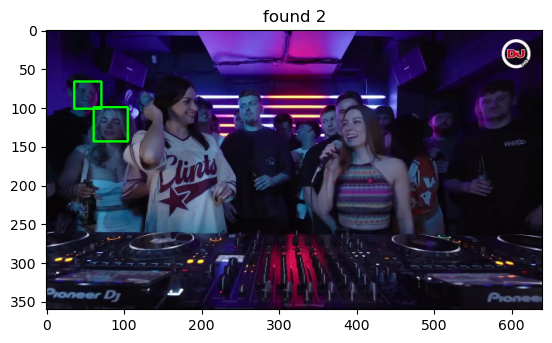

checking frame_00001.jpg


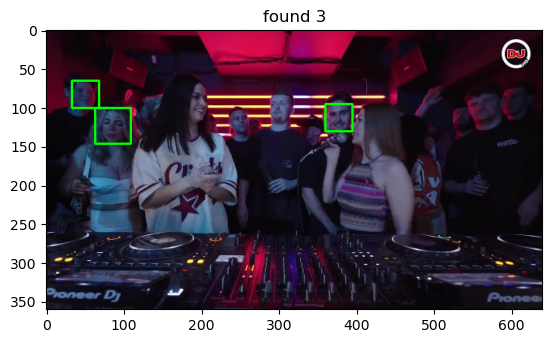

checking frame_00002.jpg


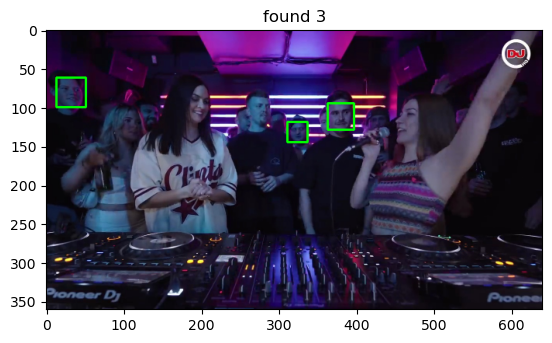

In [4]:
import os
import cv2
import matplotlib.pyplot as plt

# just testing on one folder for now
folder = "filtered_frames/ALISHA Groovy Tech-House DJ Set Live From DJ Mag HQ - DJ Mag (720p, h264, youtube)" # I'll just hardcode the path to check
files = os.listdir(folder)
files.sort()

face_xml = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
detector = cv2.CascadeClassifier(face_xml)

for i in range(3):
    img_name = files[i]
    if not img_name.endswith(".jpg"):
        continue
        
    print("checking " + img_name)
    
    img = cv2.imread(folder + "/" + img_name)
    img = cv2.resize(img, (640, 360))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    faces = detector.detectMultiScale(gray, 1.1, 5)
    
    # draw boxes
    for (x, y, w, h) in faces:
        cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)
    
    # fix colors for matplotlib
    img_final = img[:, :, ::-1] 
    
    plt.imshow(img_final)
    plt.title("found " + str(len(faces)))
    plt.show()


NameError: name 'X_features' is not defined

In [14]:
density_df = get_crowd_density_for_all_sets(base_folder="filtered_frames", fps=2)
print(density_df.head(10))
density_df.to_csv("crowd_density_metrics.csv", index=False)


Processing DJ Sets:   0%|          | 0/13 [00:00<?, ?it/s]

Starting Density Calc: Yaeji  Boiler Room New York - Boiler Room (720p, h264) (806 frames)
Starting Density Calc: Funky Disco & House Mix Inside a Circus  Felix da Housecat - Book Club Radio (720p, h264, youtube) (454 frames)
Starting Density Calc: Yung Singh  Boiler Room Melbourne - Boiler Room (720p, h264, youtube) (497 frames)
Starting Density Calc: ALISHA Groovy Tech-House DJ Set Live From DJ Mag HQ - DJ Mag (720p, h264, youtube) (894 frames)
Starting Density Calc: Fred again.. ｜ Boiler Room： London (9160 frames)
Starting Density Calc: KETTAMA  Boiler Room London - Boiler Room (720p, h264) (267 frames)
Starting Density Calc: Marlon Hoffstadt  Boiler Room Melbourne - Boiler Room (720p, h264) (10032 frames)
Starting Density Calc: AZYR  Boiler Room x Teletech Festival 2023 - Boiler Room (720p, h264) (592 frames)
Starting Density Calc: ¥ØUUK€ ¥UK1MATU  Boiler Room Tokyo - Boiler Room (720p, h264) (470 frames)
Starting Density Calc: Chase & Status  Boiler Room London - Boiler Room (720p

In [18]:
# we borrowed the has_dj_equipment 
def has_dj_equipment(frame, threshold=0.1):
    # check if the bottom half of the frame has a lot of hard edges
    # thats usually where the DJ decks/mixer/laptop are
    
    # get the size of the image
    h, w, channels = img.shape
    
    # just cut the image in half to look at the bottom
    bottom_part = img[int(h/2):, :]
    
    gray = cv2.cvtColor(bottom_part, cv2.COLOR_BGR2GRAY)
    lines = cv2.Canny(gray, 50, 150)
    
    # count how many white pixels (edges) we have
    white_pixels = np.sum(lines > 0)
    total_area = lines.shape[0] * lines.shape[1]
    
    how_busy = white_pixels / total_area
    
    if how_busy > limit:
        return True
    else:
        return False

def filter_frames(frames_dir, output_dir, threshold=0.1):
    # make the new folder if its not there
    if not os.path.exists(out_folder):
        os.makedirs(out_folder)
        
    count = 0
    all_files = os.listdir(in_folder)
    
    for name in all_files:
        if name.endswith(".jpg"):
            full_path = in_folder + "/" + name
            frame = cv2.imread(full_path)
            
            if frame is not None:
                if check_for_gear(frame):
                    cv2.imwrite(out_folder + "/" + name, frame)
                    count = count + 1
                    
    print("kept " + str(count) + "images out of" + str(len(all_files)))



testing image: frame_00019.jpg
how busy score is: 0.09369140625
Original image (red line marks the cut):


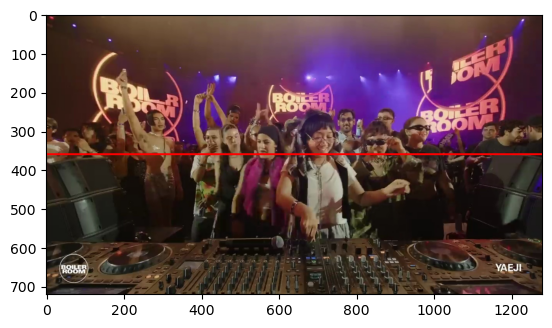

Canny edges on bottom half:


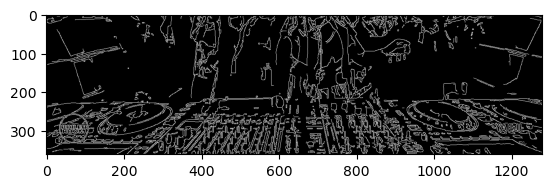

In [22]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

in_folder = "filtered_frames"
dj_folders = os.listdir(in_folder)

# get the first dj folder that isn't a hidden mac file
target_folder = ""
for folder in dj_folders:
    if not folder.startswith("."):
        target_folder = folder
        break

test_folder = in_folder + "/" + target_folder
all_files = os.listdir(test_folder)

# We will loop until we find a busy image!
name = ""
img = None
how_busy = 0

for f in all_files:
    if f.endswith(".jpg"):
        full_path = test_folder + "/" + f
        temp_img = cv2.imread(full_path)
        
        if temp_img is None:
            continue
            
        # calc the busy score for this specific image
        h, w, channels = temp_img.shape
        bottom_part = temp_img[int(h/2):, :]
        gray = cv2.cvtColor(bottom_part, cv2.COLOR_BGR2GRAY)
        lines = cv2.Canny(gray, 50, 150)
        
        white_pixels = np.sum(lines > 0)
        total_area = lines.shape[0] * lines.shape[1]
        score = white_pixels / total_area
        
        # Check if it hits your 0.1 limit!
        if score > 0.08:
            name = f
            img = temp_img
            how_busy = score
            break # We found one! Stop searching!

if img is None:
    print("Could not find any image with a busy score over 0.1!")
else:
    print("testing image: " + name)
    print("how busy score is: " + str(how_busy))

    # show the original with a red split line
    h, w, channels = img.shape
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    cv2.line(img_rgb, (0, int(h/2)), (w, int(h/2)), (255, 0, 0), 4)

    print("Original image (red line marks the cut):")
    plt.imshow(img_rgb)
    plt.show()

    # show the edges
    bottom_part = img[int(h/2):, :]
    gray = cv2.cvtColor(bottom_part, cv2.COLOR_BGR2GRAY)
    lines = cv2.Canny(gray, 50, 150)
    
    print("Canny edges on bottom half:")
    plt.imshow(lines, cmap="gray")
    plt.show()


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

in_folder = "filtered_frames"
dj_folders = os.listdir(in_folder)

# get the first dj folder that isn't a hidden mac file
target_folder = ""
for folder in dj_folders:
    if not folder.startswith("."):
        target_folder = folder
        break

test_folder = in_folder + "/" + target_folder
all_files = os.listdir(test_folder)

# pick the first image
name = ""
for f in all_files:
    if f.endswith(".jpg"):
        name = f
        break

full_path = test_folder + "/" + name
img = cv2.imread(full_path)

# size and cut
h, w, channels = img.shape
bottom_part = img[int(h/2):, :]

gray = cv2.cvtColor(bottom_part, cv2.COLOR_BGR2GRAY)
lines = cv2.Canny(gray, 50, 150)

# count busy edges
white_pixels = np.sum(lines > 0)
total_area = lines.shape[0] * lines.shape[1]
how_busy = white_pixels / total_area

print("testing image: " + name)
print("how busy score is: " + str(how_busy))

# show the original with a red split line
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
cv2.line(img_rgb, (0, int(h/2)), (w, int(h/2)), (255, 0, 0), 4)

print("Original image (red line marks the cut):")
plt.imshow(img_rgb)
plt.show()

# show the edges
print("Canny edges on bottom half:")
plt.imshow(lines, cmap="gray")
plt.show()


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd

def analyze_video_motion_lk(video_path, target_fps=5):
    cap = cv2.VideoCapture(video_path)
    
    if not cap.isOpened():
        print("Can't open this video: " + video_path)
        return None

    fps_from_video = cap.get(cv2.CAP_PROP_FPS)
    if fps_from_video <= 0:
        fps_from_video = 30 # standard backup
        
    # only check every few frames to save time
    skip_amount = int(fps_from_video / target_fps)
    if skip_amount < 1:
        skip_amount = 1

    success, first_frame = cap.read()
    if not success:
        return None
        
    first_frame = cv2.resize(first_frame, (640, 360))
    prev_gray = cv2.cvtColor(first_frame, cv2.COLOR_BGR2GRAY)
    
    # find some corners to track
    # maxCorners=100, quality=0.3, minDistance=7
    old_points = cv2.goodFeaturesToTrack(prev_gray, 100, 0.3, 7, mask=None)

    motion_results = []
    count = 0
    
    while True:
        success, frame = cap.read()
        if not success:
            break # end of video
            
        count = count + 1

        if count % skip_amount != 0:
            continue

        frame = cv2.resize(frame, (640, 360))
        current_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # if we dont have enough points find new ones
        if old_points is None or len(old_points) < 10:
            old_points = cv2.goodFeaturesToTrack(prev_gray, 100, 0.3, 7)
            
        if old_points is None:
            motion_results.append({'time': count / fps_from_video, 'motion': 0.0})
            prev_gray = current_gray.copy()
            continue

        #LK flow
        # winsize 15x15
        new_points, status, error = cv2.calcOpticalFlowPyrLK(prev_gray, current_gray, old_points, None, winSize=(15, 15), maxLevel=2)

        if new_points is not None:
            tracked_new = new_points[status == 1]
            tracked_old = old_points[status == 1]

            if len(tracked_new) > 0:
                # distance: sqrt((x2-x1)^2 + (y2-y1)^2)
                diffs = tracked_new - tracked_old
                sq_diffs = diffs ** 2
                dist_list = np.sqrt(sq_diffs[:, 0] + sq_diffs[:, 1])
                avg_val = float(np.mean(dist_list))
            else:
                avg_val = 0.0
        else:
            avg_val = 0.0

        motion_results.append({
            'time': count / fps_from_video,
            'motion': avg_val
        })

        prev_gray = current_gray.copy()
        # refresh points every time so they dont drift
        old_points = cv2.goodFeaturesToTrack(prev_gray, 100, 0.3, 7)

    cap.release()
    
    df = pd.DataFrame(motion_results)
    return df

# shortcut in case I use the other name
def get_motion_lk(video_path, target_fps=5):
    return analyze_video_motion_lk(video_path, target_fps)


In [10]:
import os
import pandas as pd

#goes throught all the videos and runs the motion lk 
def process_all_dj_sets(folder_path, fps=5):
    all_data = []
    
    files = os.listdir(folder_path)
    print("Found " + str(len(files)) + " files in the folder.")
    
    for file in files:
        if file.endswith(".mp4"):
            video_full_path = folder_path + "/" + file
            
            name_only = file.replace(".mp4", "")
            print("Starting on: " + name_only)
            
            video_df = analyze_video_motion_lk(video_full_path, target_fps=fps)
            
            if video_df is not None:
                video_df["video_name"] = name_only
                
                all_data.append(video_df)

                
    if len(all_data) > 0:
        big_df = pd.concat(all_data)
        return big_df
    else:
        print("Nothing was found or processed.")
        return None

path = "/Users/fokia/CentraleSupelec-CV-and-RL-project/dj_sets_videos"

final_motion_df = process_all_dj_sets(path, 5)

# save it so I dont have to run it again (takes forever)
if final_motion_df is not None:
    final_motion_df.to_csv("all_motion_results.csv", index=False)
    print("saved to csv")
    print(final_motion_df.head())


Found 13 files in the folder.
Starting on: Funky Disco & House Mix Inside a Circus  Felix da Housecat - Book Club Radio (720p, h264, youtube)
Finished Funky Disco & House Mix Inside a Circus  Felix da Housecat - Book Club Radio (720p, h264, youtube)
Starting on: ALISHA Groovy Tech-House DJ Set Live From DJ Mag HQ - DJ Mag (720p, h264, youtube)
Finished ALISHA Groovy Tech-House DJ Set Live From DJ Mag HQ - DJ Mag (720p, h264, youtube)
Starting on: KETTAMA  Boiler Room London - Boiler Room (720p, h264)


[NULL @ 0x16e5a1410] Invalid NAL unit size (2690 > 384).
[NULL @ 0x16e5a1410] missing picture in access unit with size 388
[h264 @ 0x31ceb3b60] Invalid NAL unit size (2690 > 384).
[h264 @ 0x31ceb3b60] Error splitting the input into NAL units.


Finished KETTAMA  Boiler Room London - Boiler Room (720p, h264)
Starting on: Minna-no-kimochi (みんなのきもち)  Boiler Room Tokyo Tohji Presents u-ha - Boiler Room (720p, h264)
Finished Minna-no-kimochi (みんなのきもち)  Boiler Room Tokyo Tohji Presents u-ha - Boiler Room (720p, h264)
Starting on: AZYR  Boiler Room x Teletech Festival 2023 - Boiler Room (720p, h264)
Finished AZYR  Boiler Room x Teletech Festival 2023 - Boiler Room (720p, h264)
Starting on: Peggy Gou  Boiler Room x Dekmantel Festival Amsterdam - Boiler Room (720p, h264, youtube)
Finished Peggy Gou  Boiler Room x Dekmantel Festival Amsterdam - Boiler Room (720p, h264, youtube)
Starting on: Chase & Status  Boiler Room London - Boiler Room (720p, h264)
Finished Chase & Status  Boiler Room London - Boiler Room (720p, h264)
Starting on: Estella Boersma  Boiler Room Festival Berlin - Boiler Room (720p, h264, youtube)
Finished Estella Boersma  Boiler Room Festival Berlin - Boiler Room (720p, h264, youtube)
Starting on: Yung Singh  Boiler Ro

[NULL @ 0x31ced1a30] Invalid NAL unit size (8944940 > 24839).
[NULL @ 0x31ced1a30] missing picture in access unit with size 24843
[h264 @ 0x31ceac570] Invalid NAL unit size (8944940 > 24839).
[h264 @ 0x31ceac570] Error splitting the input into NAL units.
[NULL @ 0x31ced1a30] Invalid NAL unit size (1788368697 > 6713).
[NULL @ 0x31ced1a30] missing picture in access unit with size 6717
[h264 @ 0x31ceb5ac0] Invalid NAL unit size (1788368697 > 6713).
[h264 @ 0x31ceb5ac0] Error splitting the input into NAL units.
[NULL @ 0x31ced1a30] Invalid NAL unit size (-1899009465 > 1856).
[NULL @ 0x31ced1a30] missing picture in access unit with size 1860
[h264 @ 0x31cebf010] Invalid NAL unit size (-1899009465 > 1856).
[h264 @ 0x31cebf010] Error splitting the input into NAL units.
[NULL @ 0x31ced1a30] Invalid NAL unit size (1171480431 > 9091).
[NULL @ 0x31ced1a30] missing picture in access unit with size 9095
[h264 @ 0x31cec8560] Invalid NAL unit size (1171480431 > 9091).
[h264 @ 0x31cec8560] Error split

Finished ¥ØUUK€ ¥UK1MATU  Boiler Room Tokyo - Boiler Room (720p, h264)
Starting on: Yaeji  Boiler Room New York - Boiler Room (720p, h264)


[NULL @ 0x320e6ec30] Invalid NAL unit size (31480702 > 24883).
[NULL @ 0x320e6ec30] missing picture in access unit with size 24887
[h264 @ 0x320ec02f0] Invalid NAL unit size (31480702 > 24883).
[h264 @ 0x320ec02f0] Error splitting the input into NAL units.
[NULL @ 0x320e6ec30] Invalid NAL unit size (777023978 > 9905).
[NULL @ 0x320e6ec30] missing picture in access unit with size 9909
[h264 @ 0x320ec9840] Invalid NAL unit size (777023978 > 9905).
[h264 @ 0x320ec9840] Error splitting the input into NAL units.
[NULL @ 0x320e6ec30] Invalid NAL unit size (843580276 > 2717).
[NULL @ 0x320e6ec30] missing picture in access unit with size 2721
[h264 @ 0x320ed2d90] Invalid NAL unit size (843580276 > 2717).
[h264 @ 0x320ed2d90] Error splitting the input into NAL units.
[NULL @ 0x320e6ec30] Invalid NAL unit size (-1950439613 > 6855).
[NULL @ 0x320e6ec30] missing picture in access unit with size 6859
[h264 @ 0x320edc2e0] Invalid NAL unit size (-1950439613 > 6855).
[h264 @ 0x320edc2e0] Error splitti

Finished Yaeji  Boiler Room New York - Boiler Room (720p, h264)
Saved to CSV!
       time    motion                                         video_name
0  0.166833  2.084591  Funky Disco & House Mix Inside a Circus  Felix...
1  0.333667  1.262306  Funky Disco & House Mix Inside a Circus  Felix...
2  0.500500  0.019647  Funky Disco & House Mix Inside a Circus  Felix...
3  0.667333  0.172856  Funky Disco & House Mix Inside a Circus  Felix...
4  0.834167  0.274512  Funky Disco & House Mix Inside a Circus  Felix...


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

video_path = "dj_sets_videos/Yung Singh  Boiler Room Melbourne - Boiler Room (720p, h264, youtube).mp4"

cap = cv2.VideoCapture(video_path)
start_frame = 38010 # a good demo I found 
# start_frame = fps of video(25 in our case) * min_desired * 60 
cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

fps = cap.get(cv2.CAP_PROP_FPS)
start_minute = (start_frame / fps) / 60.0

ret, old_frame = cap.read()
old_frame = cv2.resize(old_frame, (640, 360))
old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)

# using quality 0.01 so it finds stuff even in dark clubs
p0 = cv2.goodFeaturesToTrack(
    old_gray, 
    maxCorners=100, 
    qualityLevel=0.01, 
    minDistance=10, 
    blockSize=7
)

# blank image for the green motion trails
mask = np.zeros_like(old_frame)

animation_frames = []

print(f"Processing 30 frames from: {video_path}...")

for i in range(30):
    ret, frame = cap.read()
    if not ret:
        break
        
    frame_resized = cv2.resize(frame, (640, 360))
    frame_gray = cv2.cvtColor(frame_resized, cv2.COLOR_BGR2GRAY)

    p1, st, err = cv2.calcOpticalFlowPyrLK(
        old_gray, 
        frame_gray, 
        p0, 
        None, 
        winSize=(15, 15), 
        maxLevel=2, 
        criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03)
    )

    good_new = p1[st == 1]
    good_old = p0[st == 1]

    # draw lines from old position to new position
    for (new, old) in zip(good_new, good_old):
        a, b = int(new[0]), int(new[1])
        c, d = int(old[0]), int(old[1])
        
        mask = cv2.line(mask, (a, b), (c, d), (0, 255, 0), 3)
        frame_resized = cv2.circle(frame_resized, (a, b), 5, (0, 255, 0), -1)

    final_img = cv2.add(frame_resized, mask)
    
    # matplotlib needs RGB not BGR
    final_img_rgb = cv2.cvtColor(final_img, cv2.COLOR_BGR2RGB)
    animation_frames.append(final_img_rgb)

    old_gray = frame_gray.copy()
    p0 = good_new.reshape(-1, 1, 2)

cap.release()

# play it back
for img in animation_frames:
    clear_output(wait=True)
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.title(f"{my_video[:35]}... at {start_minute:.2f} mins", fontsize=14, fontweight="bold")
    plt.axis("off")
    plt.show()
    time.sleep(0.08) # pause a little so it looks like a video



NameError: name 'my_video' is not defined

In [3]:
#test it
df = get_motion_lk("/Users/fokia/CentraleSupelec-CV-and-RL-project/dj_sets_videos/AZYR  Boiler Room x Teletech Festival 2023 - Boiler Room (720p, h264).mp4")

Processed 6000 / 89679 frames...
Processed 12000 / 89679 frames...
Processed 18000 / 89679 frames...
Processed 24000 / 89679 frames...
Processed 30000 / 89679 frames...
Processed 36000 / 89679 frames...
Processed 42000 / 89679 frames...
Processed 48000 / 89679 frames...
Processed 54000 / 89679 frames...
Processed 60000 / 89679 frames...
Processed 66000 / 89679 frames...
Processed 72000 / 89679 frames...
Processed 78000 / 89679 frames...
Processed 84000 / 89679 frames...


In [5]:
df

,time,motion
0,0.48,0.000000
1,0.96,4.707239
2,1.44,0.804446
3,1.92,1.200536
4,2.40,1.002996
...,...,...
7468,3585.12,45.877670
7469,3585.60,55.266350
7470,3586.08,43.051849
7471,3586.56,52.210735
